# Project 2 · 01：PTQ、W8A8、Q/DQ 与 Custom NPU compiler contract

> **一句话心智模型：** quantization 不是“把 float tensor 强转成 `int8`”，而是先用 calibration 决定每个整数格代表多少真实数值（`scale / zero-point`），再把这份低精度意图写进 graph；只有 compiler 真正消除/融合 Q/DQ、选择 INT8 kernel，并由 profiler 证明硬件执行发生变化，才可能得到真实收益。

这是 `Learning-Guide.md` 中 **Project 2 — Compiler-aware Quantization & Mixed Precision** 的第一份实验。它先建立 P2.1 Quantization Baseline；P2.2 layer sensitivity、P2.3 selective fallback 和 Pareto search 会在后续 notebook 继续复用本实验的 artifact contract。

完成本实验后，你应该能从第一性原理回答：

1. `scale`、`zero-point`、rounding 和 saturation 在物理上分别做什么？
2. 为什么 weights 可直接统计，而 activations 必须通过 calibration data 观察？
3. 为什么需要 `CalibrationDataReader`、Q/DQ node、per-channel config 和 post-optimization graph dump 这些新接口？
4. 如何区分“graph 中有 Q/DQ”“compiler 选了 quantized op”“硬件真的更快”这三层证据？
5. 把同一份 W8A8 QDQ ONNX 交给公司 Custom NPU 后，应该测试、dump、profile 和归因哪些内容？

## Goal：从 Project 1 的已有状态，推导为什么现在需要 quantization 接口

Project 1 已经建立：

```text
fixed model / input
      ↓
FP32 / FP16 reference output
      ↓
ONNX / MIL graph inspection
      ↓
correctness gate
      ↓
warm latency + profiler evidence
```

但 FP16 baseline 仍没有回答：**Custom NPU 的 INT8 MAC、较小 SRAM/DRAM traffic 和更高吞吐怎样被模型正确使用？**

为获得这项额外能力，software stack 必须补上四类信息：

| 已达到的状态 | 还缺什么 | 因此引入的新功能 / 接口 |
|---|---|---|
| graph 只有 float tensor 的 shape/dtype | float 值怎样映射到有限整数格 | `scale`、`zero-point`、`QuantizeLinear` / `DequantizeLinear` |
| weights 是静态常量 | runtime activation 的真实范围未知 | representative calibration dataset、`CalibrationDataReader` |
| 所有层共享默认精度 | 不同 channel / layer 的数值范围不同 | per-channel config；后续 layer sensitivity / selective fallback |
| frontend graph 表达了 W8A8 意图 | backend 是否支持 shape、signedness、granularity 未知 | support matrix、partition/lowering dump、fallback report |
| compiler 声称“INT8” | 不知道选了什么 kernel、转换边界是否抵消收益 | optimized graph、kernel mapping、profiler、统一 benchmark |

把这条因果链记住：

```text
calibration → quant params → QDQ graph → pattern/partition → INT8 kernel → hardware counters
```

**Q/DQ 很重要，所以会在本 notebook 多次重复：Q/DQ 是 precision contract，不是加速证明。**

## 本实验边界：先做 P2.1，不假装一次做完整个 Project 2

本 notebook 默认使用一个 `Linear → ReLU → Linear → ReLU → Linear` toy MLP。输入 `[32, 256]` 可理解为 32 个 token、每个 token 有 256 个 feature；它让 MatMul/Gemm、Q/DQ boundary 和 per-output-channel scale 都容易观察，同时几秒内可完整重跑。

| 本次完成 | 后续再做 | 为什么现在不做 |
|---|---|---|
| symmetric INT8 第一性原理 | W4A8 | ONNX Runtime 的通用 INT4 路径主要是特定 MatMul 的 block-wise weight-only；Custom NPU 的真 W4A8 必须先确认硬件/kernel contract，不能只改一个 dtype 假装完成 |
| PTQ static calibration + W8A8 QDQ | QAT / SmoothQuant | 先用最主流、最小的 PTQ baseline 定位问题，再引入训练或 model transform |
| per-tensor vs per-channel weight error | layer sensitivity / selective fallback | 先建立全 INT8 baseline，下一本再逐层恢复 FP16 并重编译 |
| ORT CPU optimized graph / profiler | 公司 NPU 实测 | Mac lane 验证方法；真实 NPU 收益必须在 SoC 台架用 vendor compiler/runtime/profiler 取证 |
| output agreement / numerical error | task accuracy | toy 数据没有真实 label；**agreement 不能叫 accuracy** |

Apple 官方资料说明 W8A8 的 Neural Engine 加速面向 A17 Pro / M4 及更新硬件；M1 不应被用来证明 Core ML W8A8 的 NPU latency 收益。因此本实验在 M1 上选择可完全检视的 ONNX Runtime CPU lane，再把相同证据链迁移到公司 Custom NPU。参考 [Core ML optimization overview](https://apple.github.io/coremltools/docs-guides/source/opt-overview.html)。

## Setup：启动方式与实验合同

从仓库根目录执行：

```bash
uv sync
uv run jupyter lab notebooks/project2_quant_compiler/01_ptq_qdq_compiler_contract.ipynb
```

本实验固定：

- `torch.manual_seed(7)` 与 NumPy seeds，保证 model/data 可重建；
- ONNX opset 18、static shape `[32, 256]`；
- ORT `CPUExecutionProvider`，不允许 session 偷偷走 `CoreMLExecutionProvider`；
- W8A8 = signed activation INT8 + signed weight INT8（S8S8）、symmetric、activation per-tensor、weight per-output-channel；
- benchmark 输入已经准备好，不包含 preprocessing / calibration / compile；
- profiler 与 benchmark 分开运行，避免 instrumentation 改变 latency。

默认 synthetic calibration data 只用于**机制教学和 smoke test**。求职项目正式报告必须换成与生产输入分布一致的 representative dataset，并使用带 label 的 evaluation set。

In [21]:
from pathlib import Path
from collections import Counter
from datetime import datetime
import hashlib
import json
import platform
import subprocess
import time

import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
import torch
from IPython.display import Markdown, display
from onnx import numpy_helper
from onnxruntime.quantization import (
    CalibrationDataReader,
    CalibrationMethod,
    QuantFormat,
    QuantType,
    quantize_static,
)
from onnxruntime.quantization.shape_inference import quant_pre_process
from torch import nn

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
RUN_ID = datetime.now().strftime("%Y%m%d-%H%M%S")
ARTIFACT_DIR = ROOT / "artifacts" / "project2_quantization"
RUN_DIR = ROOT / "results" / "project2_quantization" / RUN_ID
PROFILE_DIR = RUN_DIR / "profiler"
for path in [ARTIFACT_DIR, RUN_DIR, PROFILE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CPU_THREADS = 4
TOKEN_COUNT = 32
HIDDEN_SIZE = 256
FFN_SIZE = 512
CLASS_COUNT = 4
INPUT_SHAPE = (TOKEN_COUNT, HIDDEN_SIZE)
CALIBRATION_BATCHES = 24
EVALUATION_BATCHES = 8
SHIFTED_BATCHES = 8
WARMUP = 50
RUNS = 800

torch.set_num_threads(CPU_THREADS)
pd.set_option("display.max_colwidth", 100)
BLUE = "#4C78A8"
ORANGE = "#F58518"
GRAY = "#9CA3AF"

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def size_mb(path: Path) -> float:
    return path.stat().st_size / 1e6

def command_output(command: list[str]) -> str:
    return subprocess.check_output(command, text=True).strip()

In [22]:
environment = {
    "run_id": RUN_ID,
    "python": platform.python_version(),
    "macOS": platform.mac_ver()[0],
    "machine": platform.machine(),
    "chip": command_output(["sysctl", "-n", "machdep.cpu.brand_string"]),
    "torch": torch.__version__,
    "onnx": onnx.__version__,
    "onnxruntime": ort.__version__,
    "ORT available providers": ort.get_available_providers(),
    "ORT experiment provider": "CPUExecutionProvider",
    "CPU threads": CPU_THREADS,
}
display(pd.Series(environment, name="value").to_frame())

,value
run_id,20260902-225231
python,3.12.11
macOS,26.6.2
machine,arm64
chip,Apple M1
torch,2.7.0
onnx,1.22.0
onnxruntime,1.29.0
ORT available providers,"[CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider]"
ORT experiment provider,CPUExecutionProvider


### 先检查 Execution Provider，防止 benchmark 偷换后端

`ort.get_available_providers()` 可能同时出现 `CoreMLExecutionProvider`，但本实验创建 session 时显式只传 `CPUExecutionProvider`。这和 Custom NPU 调试时显式锁定 device / partition policy 是同一原则：**没有固定 backend，就不知道测到的是谁。**

## Steps 1：从一个 tensor 推出 linear quantization

**好懂版：** 先找一个浮点范围，再把这个范围切成有限个整数格。`scale` 就是“相邻两个整数码之间隔多少 float 数值”；`zero-point` 是“哪一个整数码代表真实的 0”。落在范围外的值只能被夹到端点，这叫 saturation / clipping。

本实验先用 symmetric INT8：整数码使用 `[-127, 127]`，真实 0 对应整数 0，因此 `zero-point = 0`。如果 tensor 的最大绝对值是 `R`，每一格就是 `R / 127`。

**紧凑写法：** 原 tensor 元素是 `x`，量化整数是 `q`，反量化近似值是 `x_hat`：

```text
scale = max(abs(x)) / 127
q      = clip(round(x / scale), -127, 127)
x_hat  = q * scale
```

注意这里的 `round + clip` 会丢信息，所以 quantization 本质上是 lossy transformation。

,calibration range,scale (float / integer step),MAE on normal values
0,"[-1, 1]",0.007874,0.001875
1,"[-1, 12]",0.094488,0.026922


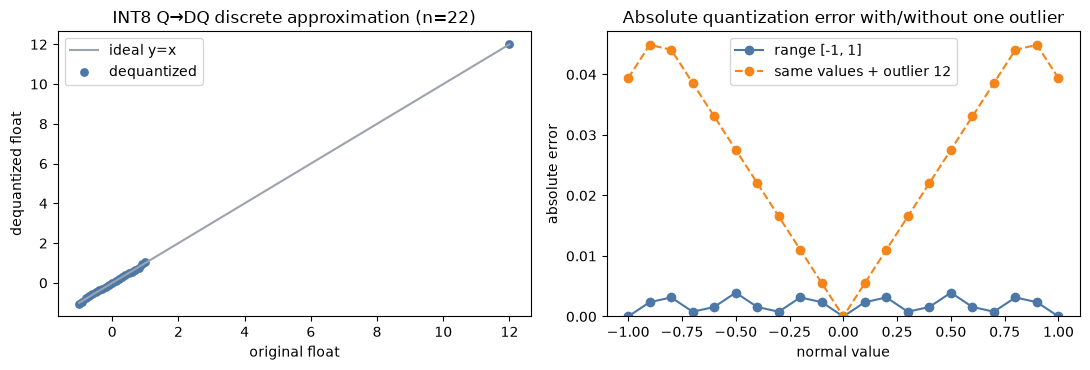

In [23]:
def symmetric_int8_qdq(tensor: np.ndarray, axis: int | None = None):
    reduce_axes = None if axis is None else tuple(
        dim for dim in range(tensor.ndim) if dim != axis
    )
    max_abs = np.max(np.abs(tensor), axis=reduce_axes, keepdims=axis is not None)
    scale = np.maximum(max_abs / 127, np.finfo(np.float32).eps)
    quantized = np.clip(np.rint(tensor / scale), -127, 127).astype(np.int8)
    dequantized = quantized.astype(np.float32) * scale
    return quantized, dequantized, scale

normal_values = np.linspace(-1, 1, 21, dtype=np.float32)
values_with_outlier = np.concatenate([normal_values, np.array([12], dtype=np.float32)])

_, normal_dequantized, normal_scale = symmetric_int8_qdq(normal_values)
outlier_quantized, outlier_dequantized, outlier_scale = symmetric_int8_qdq(values_with_outlier)

toy_summary = pd.DataFrame(
    [
        {
            "calibration range": "[-1, 1]",
            "scale (float / integer step)": float(normal_scale),
            "MAE on normal values": np.mean(np.abs(normal_values - normal_dequantized)),
        },
        {
            "calibration range": "[-1, 12]",
            "scale (float / integer step)": float(outlier_scale),
            "MAE on normal values": np.mean(
                np.abs(normal_values - outlier_dequantized[:-1])
            ),
        },
    ]
)
display(toy_summary.style.format({
    "scale (float / integer step)": "{:.6f}",
    "MAE on normal values": "{:.6f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(values_with_outlier, values_with_outlier, color=GRAY, label="ideal y=x")
axes[0].scatter(
    values_with_outlier, outlier_dequantized, s=28, color=BLUE, label="dequantized"
)
axes[0].set(
    title="INT8 Q→DQ discrete approximation (n=22)",
    xlabel="original float",
    ylabel="dequantized float",
)
axes[0].legend()

axes[1].plot(
    normal_values,
    np.abs(normal_values - normal_dequantized),
    marker="o",
    color=BLUE,
    label="range [-1, 1]",
)
axes[1].plot(
    normal_values,
    np.abs(normal_values - outlier_dequantized[:-1]),
    marker="o",
    linestyle="--",
    color=ORANGE,
    label="same values + outlier 12",
)
axes[1].set(
    title="Absolute quantization error with/without one outlier",
    xlabel="normal value",
    ylabel="absolute error",
    ylim=(0, None),
)
axes[1].legend()
fig.tight_layout()
plt.show()

**观察：** INT8 code 数量没有变化；outlier 占用了大部分动态范围，于是普通值落到更稀疏的整数格上。这个现象直接解释了为什么 calibration dataset 要 representative，也解释了后续为什么会出现 Percentile calibration、SmoothQuant 和 layer sensitivity。

但不能为了数值好看随便裁掉 outlier：如果它是生产输入中的真实高频值，裁剪会造成 saturation。正确做法是先统计出现率和业务影响，再决定 clipping 策略。

## Steps 2：构造一个可映射到 NPU MatMul kernel 的 toy workload

模型不是为了刷 accuracy，而是为了看清 compiler pipeline：

```text
input [M=32, K=256]
      ↓
Gemm [256 → 512] + ReLU
      ↓
Gemm [512 → 512] + ReLU
      ↓
Gemm [512 → 4]
```

对 NPU 来说，`M/N/K`、dtype 和 layout 决定某个 kernel 能不能选中；这里的维度都对 16/32 友好，方便未来与公司 NPU 的 tiling/alignment constraint 对照。

为让 per-tensor / per-channel 的差异成为可观察的控制变量，我们会把 `fc1` 各 output channel 的 weight amplitude 固定拉开到 `0.1×–1.0×`。这是 toy workload 的实验设计，不是训练算法；真实训练后模型也常出现 channel range 不一致，但必须以实际 weight statistics 为准。

In [24]:
torch.manual_seed(7)

class TinyTokenMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(HIDDEN_SIZE, FFN_SIZE)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(FFN_SIZE, FFN_SIZE)
        self.relu2 = nn.ReLU()
        self.head = nn.Linear(FFN_SIZE, CLASS_COUNT)

    def forward(self, inputs):
        hidden = self.relu1(self.fc1(inputs))
        hidden = self.relu2(self.fc2(hidden))
        return self.head(hidden)

model = TinyTokenMLP().eval()
with torch.no_grad():
    output_channel_amplitude = torch.logspace(-1, 0, FFN_SIZE).unsqueeze(1)
    model.fc1.weight.mul_(output_channel_amplitude)

def make_token_matrices(
    count: int,
    seed: int,
    scale: float = 1.0,
    inject_outliers: bool = False,
) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    feature_phase = np.linspace(0, 4 * np.pi, HIDDEN_SIZE, dtype=np.float32)
    samples = []
    for sample_index in range(count):
        values = rng.normal(size=INPUT_SHAPE).astype(np.float32)
        values += 0.15 * np.sin(feature_phase + sample_index / 3)
        values *= scale
        if inject_outliers and sample_index % 4 == 0:
            values[:4, :16] *= 10
        samples.append(np.ascontiguousarray(values))
    return samples

calibration_inputs = make_token_matrices(CALIBRATION_BATCHES, seed=101)
evaluation_inputs = make_token_matrices(EVALUATION_BATCHES, seed=202)
shifted_inputs = make_token_matrices(
    SHIFTED_BATCHES, seed=303, scale=2.5, inject_outliers=True
)

with torch.no_grad():
    example_output = model(torch.from_numpy(calibration_inputs[0])).numpy()

macs_per_forward = TOKEN_COUNT * (
    HIDDEN_SIZE * FFN_SIZE + FFN_SIZE * FFN_SIZE + FFN_SIZE * CLASS_COUNT
)
model_contract = {
    "model": "TinyTokenMLP",
    "input_shape": list(INPUT_SHAPE),
    "input_dtype": "float32",
    "output_shape": list(example_output.shape),
    "parameters": sum(parameter.numel() for parameter in model.parameters()),
    "MACs_per_forward": macs_per_forward,
    "calibration_batches": CALIBRATION_BATCHES,
    "evaluation_batches": EVALUATION_BATCHES,
    "tokens_per_batch": TOKEN_COUNT,
}
display(pd.Series(model_contract, name="value").to_frame())

,value
model,TinyTokenMLP
input_shape,"[32, 256]"
input_dtype,float32
output_shape,"[32, 4]"
parameters,396292
MACs_per_forward,12648448
calibration_batches,24
evaluation_batches,8
tokens_per_batch,32


## Steps 3：为什么 weights 常用 per-channel，而 activation baseline 常用 per-tensor

`fc1.weight` 的内部数据结构是 `[output_channel=512, input_channel=256]`。如果整块 weight 共用一个 `scale`，最大范围的 output channel 会替所有 channel 决定整数格；小范围 channel 就浪费了很多 code。

`per_channel=True` 给每个 output channel 一个独立 scale。它增加少量 metadata，却通常显著降低 weight reconstruction error；很多 INT8 GEMM/Conv kernel 能把这个 scale 沿 accumulator 的 output channel 方向应用。

activation 也可以 per-channel，但 runtime tensor 的 layout、scale broadcast 和 kernel 支持更复杂。第一份 baseline 先使用主流、兼容性更高的 activation per-tensor + weight per-channel，并在公司 NPU support matrix 中确认真实限制。

,granularity,scale count,mean weight MAE,worst-channel MAE
0,per-tensor,1,0.00012251,0.00013785
1,per-output-channel,512,0.00004777,0.00012996


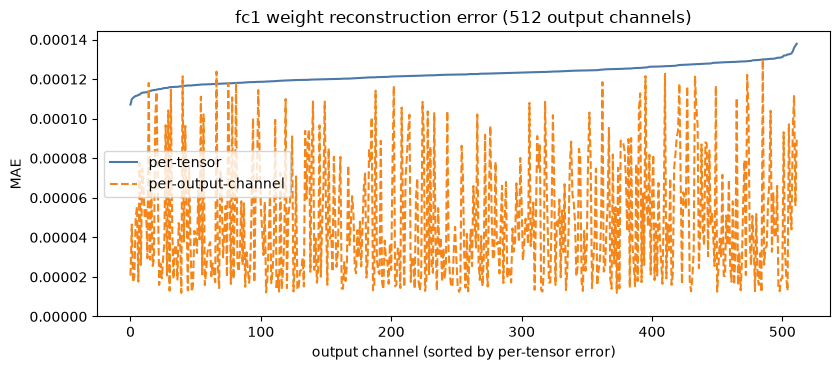

In [25]:
fc1_weight = model.fc1.weight.detach().numpy()
_, weight_per_tensor_dq, weight_per_tensor_scale = symmetric_int8_qdq(fc1_weight)
_, weight_per_channel_dq, weight_per_channel_scale = symmetric_int8_qdq(
    fc1_weight, axis=0
)

per_tensor_channel_mae = np.mean(np.abs(fc1_weight - weight_per_tensor_dq), axis=1)
per_channel_channel_mae = np.mean(np.abs(fc1_weight - weight_per_channel_dq), axis=1)
weight_error_summary = pd.DataFrame(
    [
        {
            "granularity": "per-tensor",
            "scale count": 1,
            "mean weight MAE": np.mean(per_tensor_channel_mae),
            "worst-channel MAE": np.max(per_tensor_channel_mae),
        },
        {
            "granularity": "per-output-channel",
            "scale count": weight_per_channel_scale.size,
            "mean weight MAE": np.mean(per_channel_channel_mae),
            "worst-channel MAE": np.max(per_channel_channel_mae),
        },
    ]
)
display(weight_error_summary.style.format({
    "mean weight MAE": "{:.8f}",
    "worst-channel MAE": "{:.8f}",
}))

order = np.argsort(per_tensor_channel_mae)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(per_tensor_channel_mae[order], color=BLUE, label="per-tensor")
ax.plot(
    per_channel_channel_mae[order],
    color=ORANGE,
    linestyle="--",
    label="per-output-channel",
)
ax.set(
    title="fc1 weight reconstruction error (512 output channels)",
    xlabel="output channel (sorted by per-tensor error)",
    ylabel="MAE",
    ylim=(0, None),
)
ax.legend()
fig.tight_layout()
plt.show()

## Steps 4：calibration 的职责是观察 activation，不是训练 model

weights 在 `.onnx` / `state_dict` 里是静态数组，compiler 可直接统计；activation 依赖真实输入，只有执行 forward 才知道范围。因此 `CalibrationDataReader` 这个接口存在的原因是：**quantizer 需要反复喂 representative input，同时不更新任何 weight。** 这就是 PTQ（Post-Training Quantization）。

下面先用 PyTorch forward hook 手工观察各层 activation。hook 类似给 runtime function call 安装 instrumentation：它不改变计算，只截取中间 tensor 供统计。

,layer,observed values,min,max,abs max,P99.9 abs,symmetric INT8 scale
0,fc1,393216,-2.2974,2.6327,2.6327,1.3870,0.020730
1,relu1,393216,0.0000,2.6327,2.6327,1.2548,0.020730
2,fc2,393216,-0.5361,0.5075,0.5361,0.3770,0.004221
3,relu2,393216,0.0000,0.5075,0.5075,0.3490,0.003996
4,head,3072,-0.1206,0.2057,0.2057,0.1855,0.001620


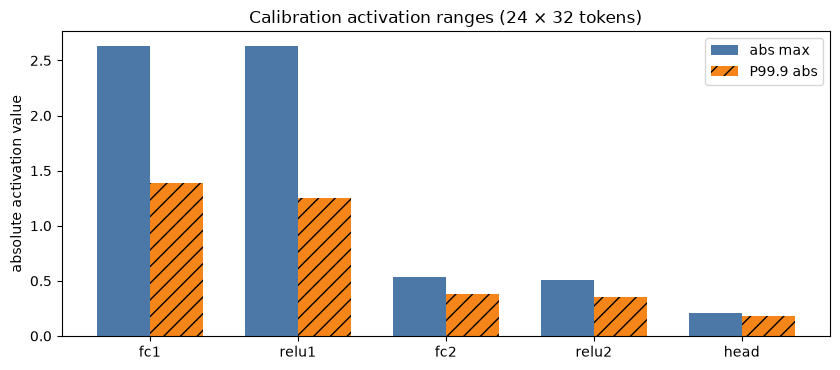

In [26]:
observed_activations: dict[str, list[np.ndarray]] = {
    name: [] for name in ["fc1", "relu1", "fc2", "relu2", "head"]
}

def save_activation(name):
    def hook(module, inputs, output):
        observed_activations[name].append(output.detach().numpy().reshape(-1))
    return hook

hooks = [
    module.register_forward_hook(save_activation(name))
    for name, module in model.named_modules()
    if name in observed_activations
]
with torch.no_grad():
    for values in calibration_inputs:
        model(torch.from_numpy(values))
for hook in hooks:
    hook.remove()

activation_rows = []
for name, chunks in observed_activations.items():
    values = np.concatenate(chunks)
    activation_rows.append(
        {
            "layer": name,
            "observed values": values.size,
            "min": values.min(),
            "max": values.max(),
            "abs max": np.max(np.abs(values)),
            "P99.9 abs": np.percentile(np.abs(values), 99.9),
            "symmetric INT8 scale": np.max(np.abs(values)) / 127,
        }
    )
activation_stats = pd.DataFrame(activation_rows)
display(activation_stats.style.format({
    "min": "{:.4f}",
    "max": "{:.4f}",
    "abs max": "{:.4f}",
    "P99.9 abs": "{:.4f}",
    "symmetric INT8 scale": "{:.6f}",
}))

x = np.arange(len(activation_stats))
width = 0.36
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.bar(
    x - width / 2,
    activation_stats["abs max"],
    width,
    color=BLUE,
    label="abs max",
)
ax.bar(
    x + width / 2,
    activation_stats["P99.9 abs"],
    width,
    color=ORANGE,
    hatch="//",
    label="P99.9 abs",
)
ax.set(
    title=f"Calibration activation ranges ({CALIBRATION_BATCHES} × {TOKEN_COUNT} tokens)",
    ylabel="absolute activation value",
    xticks=x,
    xticklabels=activation_stats["layer"],
    ylim=(0, None),
)
ax.legend()
fig.tight_layout()
plt.show()

**怎么解读：** 每层需要自己的 activation scale；不能拿 input scale 套全图。MinMax calibration 会用观察到的 extrema，简单、主流、适合第一份 baseline，但对 outlier 敏感。Percentile / Entropy 是后续可比较的 calibration policy，不应在 baseline 失败前盲目堆参数。

再重复一次重要边界：calibration batch 数量不是越大就自动越好；关键是覆盖 production distribution、shape bucket 和重要长尾输入。

## Steps 5：export FP32 ONNX，并先做 quantization pre-process

ONNX 用 Protobuf 保存 `ModelProto → GraphProto → NodeProto / TensorProto`。quantizer 最好在 tensor shape 已知、可融合结构已经规整的 graph 上工作，因此 ONNX Runtime 官方流程先调用 `quant_pre_process()`，把 shape inference / graph optimization 与 quantization 分开；这样发生数值问题时也更容易做 graph matching。

这里的新接口不是“多余的一步”：**quantizer 要知道 tensor shape 和稳定 node identity，才能决定 per-channel axis、插入 Q/DQ，并在之后做 activation matching。**

In [27]:
FP32_ONNX = ARTIFACT_DIR / "tiny_token_mlp_fp32.onnx"
PREPROCESSED_ONNX = ARTIFACT_DIR / "tiny_token_mlp_fp32_preprocessed.onnx"

export_start = time.perf_counter_ns()
torch.onnx.export(
    model,
    (torch.from_numpy(calibration_inputs[0]),),
    FP32_ONNX,
    input_names=["input"],
    output_names=["logits"],
    opset_version=18,
    dynamo=False,
)
export_ms = (time.perf_counter_ns() - export_start) / 1e6

preprocess_start = time.perf_counter_ns()
quant_pre_process(FP32_ONNX, PREPROCESSED_ONNX, skip_optimization=False)
preprocess_ms = (time.perf_counter_ns() - preprocess_start) / 1e6

fp32_model = onnx.load(PREPROCESSED_ONNX)
onnx.checker.check_model(fp32_model)
fp32_op_counts = Counter(node.op_type for node in fp32_model.graph.node)
fp32_nodes = pd.DataFrame(
    [
        {
            "name": node.name,
            "op_type": node.op_type,
            "inputs": list(node.input),
            "outputs": list(node.output),
        }
        for node in fp32_model.graph.node
    ]
)
print(
    f"export={export_ms:.2f} ms, preprocess={preprocess_ms:.2f} ms, "
    f"nodes={len(fp32_model.graph.node)}, size={size_mb(PREPROCESSED_ONNX):.3f} MB"
)
display(pd.DataFrame(fp32_op_counts.items(), columns=["op_type", "count"]))
display(fp32_nodes)

export=209.91 ms, preprocess=143.58 ms, nodes=5, size=1.586 MB


,op_type,count
0,Gemm,3
1,Relu,2


,name,op_type,inputs,outputs
0,/fc1/Gemm,Gemm,"[input, fc1.weight, fc1.bias]",[/fc1/Gemm_output_0]
1,/relu1/Relu,Relu,[/fc1/Gemm_output_0],[/relu1/Relu_output_0]
2,/fc2/Gemm,Gemm,"[/relu1/Relu_output_0, fc2.weight, fc2.bias]",[/fc2/Gemm_output_0]
3,/relu2/Relu,Relu,[/fc2/Gemm_output_0],[/relu2/Relu_output_0]
4,/head/Gemm,Gemm,"[/relu2/Relu_output_0, head.weight, head.bias]",[logits]


最小的结构验证 CLI：

```bash
uv run python -c "import onnx; onnx.checker.check_model(onnx.load('artifacts/project2_quantization/tiny_token_mlp_fp32_preprocessed.onnx'))"
```

`onnx.load` 把 Protobuf 反序列化为 Python `ModelProto`；`checker` 检查 schema、input/output 和 attribute 是否符合 ONNX contract。它只验证结构合法，不验证数值正确或 backend 支持。

## Steps 6：用 static PTQ 生成 W8A8 QDQ graph

当前 graph 仍只有 FP32 `Gemm / Relu`。为了让 frontend 把“这里应按 INT8 近似”交给不同 backend，我们需要一种 backend-neutral 表达：在 float op 周围插入 `QuantizeLinear / DequantizeLinear`，并把 calibration 得到的 `scale / zero-point` 保存成 initializer。

这就是 QDQ format：

```text
float activation
      ↓ QuantizeLinear(scale, zero_point)
int8 activation
      ↓ DequantizeLinear(scale, zero_point)
float-typed Gemm node（携带 quantization intent）
```

backend optimizer 可以匹配这段 pattern，并改写为 `QGemm` / INT8 kernel。**raw graph 中 Q/DQ 越多，不代表越快；理想状态是内部连续 INT8 subgraph，边界 Q/DQ 尽量少。**

In [28]:
class ArrayCalibrationReader(CalibrationDataReader):
    def __init__(self, samples: list[np.ndarray]):
        self.samples = samples
        self.rewind()

    def get_next(self):
        return next(self.iterator, None)

    def rewind(self):
        self.iterator = iter({"input": values} for values in self.samples)

W8A8_QDQ_ONNX = ARTIFACT_DIR / "tiny_token_mlp_w8a8_qdq.onnx"
quantize_start = time.perf_counter_ns()
quantize_static(
    PREPROCESSED_ONNX,
    W8A8_QDQ_ONNX,
    ArrayCalibrationReader(calibration_inputs),
    quant_format=QuantFormat.QDQ,
    per_channel=True,
    activation_type=QuantType.QInt8,
    weight_type=QuantType.QInt8,
    calibrate_method=CalibrationMethod.MinMax,
    calibration_providers=["CPUExecutionProvider"],
    extra_options={
        "ActivationSymmetric": True,
        "WeightSymmetric": True,
    },
)
quantize_ms = (time.perf_counter_ns() - quantize_start) / 1e6

qdq_model = onnx.load(W8A8_QDQ_ONNX)
onnx.checker.check_model(qdq_model)
qdq_op_counts = Counter(node.op_type for node in qdq_model.graph.node)
print(
    f"quantize={quantize_ms:.2f} ms, nodes={len(qdq_model.graph.node)}, "
    f"size={size_mb(W8A8_QDQ_ONNX):.3f} MB"
)
display(pd.DataFrame(qdq_op_counts.most_common(), columns=["op_type", "count"]))

quantize=128.86 ms, nodes=23, size=0.418 MB


,op_type,count
0,DequantizeLinear,12
1,QuantizeLinear,6
2,Gemm,3
3,Relu,2


In [29]:
initializer_map = {
    initializer.name: numpy_helper.to_array(initializer)
    for initializer in qdq_model.graph.initializer
}
quant_parameter_rows = []
for name, values in initializer_map.items():
    if "scale" not in name and "zero_point" not in name:
        continue
    quant_parameter_rows.append(
        {
            "initializer": name,
            "shape": list(values.shape),
            "dtype": str(values.dtype),
            "min": values.min(),
            "max": values.max(),
            "meaning": "one value = per-tensor" if values.ndim == 0 else "vector = per-channel",
        }
    )
quant_parameter_df = pd.DataFrame(quant_parameter_rows)
display(quant_parameter_df.head(18))

qdq_preview = pd.DataFrame(
    [
        {
            "name": node.name,
            "op_type": node.op_type,
            "inputs": list(node.input),
            "outputs": list(node.output),
        }
        for node in qdq_model.graph.node
        if node.op_type in {"QuantizeLinear", "DequantizeLinear", "Gemm", "Relu"}
    ]
)
display(qdq_preview.head(24))

,initializer,shape,dtype,min,max,meaning
0,input_zero_point,[],int8,0.000000,0.000000,one value = per-tensor
1,input_scale,[],float32,0.034859,0.034859,one value = per-tensor
2,/fc1/Gemm_output_0_zero_point,[],int8,0.000000,0.000000,one value = per-tensor
3,/fc1/Gemm_output_0_scale,[],float32,0.020730,0.020730,one value = per-tensor
4,fc1.weight_zero_point,[512],int8,0.000000,0.000000,vector = per-channel
5,fc1.weight_scale,[512],float32,0.000049,0.000490,vector = per-channel
6,/relu1/Relu_output_0_zero_point,[],int8,0.000000,0.000000,one value = per-tensor
7,/relu1/Relu_output_0_scale,[],float32,0.020730,0.020730,one value = per-tensor
8,/fc2/Gemm_output_0_zero_point,[],int8,0.000000,0.000000,one value = per-tensor
9,/fc2/Gemm_output_0_scale,[],float32,0.003996,0.003996,one value = per-tensor


,name,op_type,inputs,outputs
0,fc1.bias_DequantizeLinear,DequantizeLinear,"[fc1.bias_quantized, fc1.bias_quantized_scale, fc1.bias_quantized_zero_point]",[fc1.bias]
1,fc1.weight_DequantizeLinear,DequantizeLinear,"[fc1.weight_quantized, fc1.weight_scale, fc1.weight_zero_point]",[fc1.weight_DequantizeLinear_Output]
2,fc2.bias_DequantizeLinear,DequantizeLinear,"[fc2.bias_quantized, fc2.bias_quantized_scale, fc2.bias_quantized_zero_point]",[fc2.bias]
3,fc2.weight_DequantizeLinear,DequantizeLinear,"[fc2.weight_quantized, fc2.weight_scale, fc2.weight_zero_point]",[fc2.weight_DequantizeLinear_Output]
4,head.bias_DequantizeLinear,DequantizeLinear,"[head.bias_quantized, head.bias_quantized_scale, head.bias_quantized_zero_point]",[head.bias]
5,head.weight_DequantizeLinear,DequantizeLinear,"[head.weight_quantized, head.weight_scale, head.weight_zero_point]",[head.weight_DequantizeLinear_Output]
6,input_QuantizeLinear,QuantizeLinear,"[input, input_scale, input_zero_point]",[input_QuantizeLinear_Output]
7,input_DequantizeLinear,DequantizeLinear,"[input_QuantizeLinear_Output, input_scale, input_zero_point]",[input_DequantizeLinear_Output]
8,/fc1/Gemm,Gemm,"[input_DequantizeLinear_Output, fc1.weight_DequantizeLinear_Output, fc1.bias]",[/fc1/Gemm_output_0]
9,/fc1/Gemm_output_0_QuantizeLinear,QuantizeLinear,"[/fc1/Gemm_output_0, /fc1/Gemm_output_0_scale, /fc1/Gemm_output_0_zero_point]",[/fc1/Gemm_output_0_QuantizeLinear_Output]


在 parameter table 中重点找：

- `input_scale` 是 scalar：本实验 activation per-tensor；
- `fc1.weight_scale` 一类 weight scale 是长度 512 的 vector：weight per-output-channel；
- symmetric INT8 的 zero-point 应为 0；
- bias 常量会进入 INT32 accumulator 对应的 scale，通常等于 `input_scale × weight_scale`。

用 Netron 直接点 graph：

```bash
uv run netron artifacts/project2_quantization/tiny_token_mlp_w8a8_qdq.onnx
```

重点沿一条 `input → Q → DQ → Gemm → Q → DQ` 路径点开 initializer。`netron` 只负责 graph inspection；不能从图形颜色判断真实 device/kernel。

## Checks 1：查看 backend optimization 后的 graph，而不是停在 raw QDQ

现在已经达到“frontend graph 表达 W8A8 intent”的状态，但我们还不知道 ORT CPU backend 是否识别 pattern。为获得这项额外证据，创建 session 时要求 ORT 保存 post-optimization graph。

对 Custom NPU，对应操作是 compiler 的 `--dump-ir / --dump-partition / --dump-lowering` 一类接口。名称由 vendor 决定，但目的相同：检查 Q/DQ 是否被消除/融合、哪些 node 进入 NPU subgraph、哪些 fallback、最终选了什么 implementation。

In [30]:
FP32_OPTIMIZED_ONNX = ARTIFACT_DIR / "tiny_token_mlp_fp32_ort_optimized.onnx"
W8A8_OPTIMIZED_ONNX = ARTIFACT_DIR / "tiny_token_mlp_w8a8_ort_optimized.onnx"

def make_ort_session(model_path: Path, optimized_path: Path | None = None):
    options = ort.SessionOptions()
    options.intra_op_num_threads = CPU_THREADS
    options.inter_op_num_threads = 1
    options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    options.log_severity_level = 3
    if optimized_path is not None:
        options.optimized_model_filepath = str(optimized_path)
    return ort.InferenceSession(
        str(model_path), options, providers=["CPUExecutionProvider"]
    )

fp32_session = make_ort_session(PREPROCESSED_ONNX, FP32_OPTIMIZED_ONNX)
w8a8_session = make_ort_session(W8A8_QDQ_ONNX, W8A8_OPTIMIZED_ONNX)

fp32_optimized_model = onnx.load(FP32_OPTIMIZED_ONNX)
w8a8_optimized_model = onnx.load(W8A8_OPTIMIZED_ONNX)
fp32_optimized_counts = Counter(
    node.op_type for node in fp32_optimized_model.graph.node
)
w8a8_optimized_counts = Counter(
    node.op_type for node in w8a8_optimized_model.graph.node
)

graph_stage_summary = pd.DataFrame(
    [
        {
            "stage": "FP32 preprocessed",
            "nodes": len(fp32_model.graph.node),
            "Q": fp32_op_counts["QuantizeLinear"],
            "DQ": fp32_op_counts["DequantizeLinear"],
            "quantized compute ops": 0,
            "op counts": dict(fp32_op_counts),
        },
        {
            "stage": "W8A8 raw QDQ",
            "nodes": len(qdq_model.graph.node),
            "Q": qdq_op_counts["QuantizeLinear"],
            "DQ": qdq_op_counts["DequantizeLinear"],
            "quantized compute ops": 0,
            "op counts": dict(qdq_op_counts),
        },
        {
            "stage": "W8A8 ORT optimized",
            "nodes": len(w8a8_optimized_model.graph.node),
            "Q": w8a8_optimized_counts["QuantizeLinear"],
            "DQ": w8a8_optimized_counts["DequantizeLinear"],
            "quantized compute ops": sum(
                w8a8_optimized_counts[name]
                for name in ["QGemm", "QLinearMatMul", "MatMulInteger"]
            ),
            "op counts": dict(w8a8_optimized_counts),
        },
    ]
)
display(graph_stage_summary)

,stage,nodes,Q,DQ,quantized compute ops,op counts
0,FP32 preprocessed,5,0,0,0,"{'Gemm': 3, 'Relu': 2}"
1,W8A8 raw QDQ,23,6,12,0,"{'DequantizeLinear': 12, 'QuantizeLinear': 6, 'Gemm': 3, 'Relu': 2}"
2,W8A8 ORT optimized,11,3,3,3,"{'QuantizeLinear': 3, 'QGemm': 3, 'DequantizeLinear': 3, 'Relu': 2}"


**证据解读：** optimized graph 中出现 `QGemm`，说明 ORT optimizer 已把 raw `Q/DQ + Gemm` pattern 改写为 quantized operator；这比“文件名里写了 int8”更强。但如果仍看到 `DQ → Relu → Q`，说明 INT8 subgraph 被 float activation 切开，conversion boundary 仍有成本。

这正是 compiler-aware quantization：精度配置不只改变数值误差，也改变 pattern、fusion、partition 和 kernel selection。后续 selective fallback 每恢复一个 FP16 layer，都必须重新检查这些边界。

## Checks 2：先过 numerical correctness gate，并把 distribution shift 单列

toy model 没有 label，所以这里只能比较 FP32 与 W8A8 的全部 logits：

- `MAE / max_abs`：逐元素误差；
- cosine similarity：每个 token 的 4 维 logit 方向是否接近；
- Top-1 agreement：两个 backend 的 argmax 是否一致；
- input saturation：evaluation 值有多少超出 calibration 得到的 INT8 可表示范围。

**Top-1 agreement 不是 task accuracy。** 只有真实 label 与任务 metric 才能回答 accuracy drop。

,dataset,tokens,FP32 predicted classes covered,input saturation %,logit MAE,logit max_abs,mean cosine,min cosine,Top-1 agreement %,task accuracy
0,in-distribution synthetic,256,3,0.002,0.001061,0.004620,0.999781,0.998419,99.22,unavailable: no labels
1,shifted + outliers synthetic,256,3,7.979,0.031662,0.616247,0.981929,0.457643,93.36,unavailable: no labels


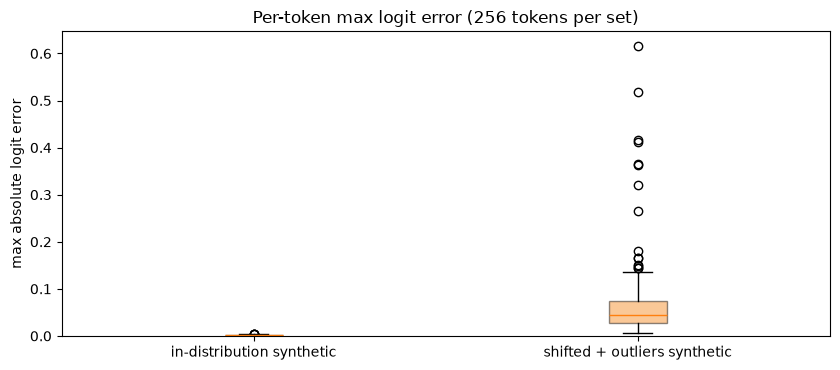

In [31]:
def run_all(session: ort.InferenceSession, samples: list[np.ndarray]) -> np.ndarray:
    return np.concatenate(
        [session.run(None, {"input": values})[0] for values in samples], axis=0
    )

def rowwise_cosine(reference: np.ndarray, candidate: np.ndarray) -> np.ndarray:
    numerator = np.sum(reference * candidate, axis=1)
    denominator = np.linalg.norm(reference, axis=1) * np.linalg.norm(candidate, axis=1)
    return numerator / denominator

input_scale = float(initializer_map["input_scale"])
input_zero_point = int(initializer_map["input_zero_point"])
input_float_min = (-127 - input_zero_point) * input_scale
input_float_max = (127 - input_zero_point) * input_scale

evaluation_sets = {
    "in-distribution synthetic": evaluation_inputs,
    "shifted + outliers synthetic": shifted_inputs,
}
output_pairs = {}
correctness_rows = []
for dataset_name, samples in evaluation_sets.items():
    fp32_outputs = run_all(fp32_session, samples)
    w8a8_outputs = run_all(w8a8_session, samples)
    output_pairs[dataset_name] = (fp32_outputs, w8a8_outputs)
    absolute_error = np.abs(fp32_outputs - w8a8_outputs)
    cosine = rowwise_cosine(fp32_outputs, w8a8_outputs)
    all_inputs = np.concatenate(samples, axis=0)
    saturation = np.mean(
        (all_inputs < input_float_min) | (all_inputs > input_float_max)
    )
    correctness_rows.append(
        {
            "dataset": dataset_name,
            "tokens": len(fp32_outputs),
            "FP32 predicted classes covered": np.unique(
                fp32_outputs.argmax(axis=1)
            ).size,
            "input saturation %": 100 * saturation,
            "logit MAE": absolute_error.mean(),
            "logit max_abs": absolute_error.max(),
            "mean cosine": cosine.mean(),
            "min cosine": cosine.min(),
            "Top-1 agreement %": 100
            * np.mean(fp32_outputs.argmax(axis=1) == w8a8_outputs.argmax(axis=1)),
            "task accuracy": "unavailable: no labels",
        }
    )

correctness_df = pd.DataFrame(correctness_rows)
assert np.isfinite(correctness_df[["logit MAE", "logit max_abs", "mean cosine"]].to_numpy()).all()
assert correctness_df.loc[
    correctness_df["dataset"] == "in-distribution synthetic", "mean cosine"
].item() > 0.99
display(correctness_df.style.format({
    "input saturation %": "{:.3f}",
    "logit MAE": "{:.6f}",
    "logit max_abs": "{:.6f}",
    "mean cosine": "{:.6f}",
    "min cosine": "{:.6f}",
    "Top-1 agreement %": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
error_distributions = [
    np.max(np.abs(reference - candidate), axis=1)
    for reference, candidate in output_pairs.values()
]
boxplot = ax.boxplot(
    error_distributions,
    tick_labels=list(output_pairs),
    showfliers=True,
    patch_artist=True,
)
for box, color in zip(boxplot["boxes"], [BLUE, ORANGE]):
    box.set_facecolor(color)
    box.set_alpha(0.45)
ax.set(
    title=f"Per-token max logit error ({TOKEN_COUNT * EVALUATION_BATCHES} tokens per set)",
    ylabel="max absolute logit error",
    ylim=(0, None),
)
fig.tight_layout()
plt.show()

**怎么验证 calibration 是否失配：** 看 shifted set 的 `input saturation %` 和 error distribution 是否一起上升。若上升，只能说明这份 calibration contract 对 shifted data 不够好；还不能直接断言某一层是根因。P2.2 会抓取 FP32/W8A8 中间 activation，按 layer 计算 SQNR/cosine，再做逐层 fallback。

## Checks 3：统一 benchmark，回答“这台机器上的这个 backend 是否更快”

benchmark 只计 `prepared tensor → host-visible logits`。calibration、quantization、session creation 都是离线/冷路径，不能混入 steady latency。

这次比较只对 **M1 + ORT CPU EP + 当前 toy shape** 有效。即使 W8A8 更快，也不能外推为 Core ML ANE 或公司 NPU 的 speedup；即使更慢，也不能推断 Custom NPU 没有 INT8 收益。

,backend,p50_ms,p95_ms,p99_ms,mean_ms,std_ms,tokens_per_second_at_p50
0,ORT CPU FP32,0.1192,0.3177,1.0256,0.1610,0.2707,"268,391"
1,ORT CPU W8A8,0.0776,0.2449,0.8340,0.1551,1.1378,"412,127"


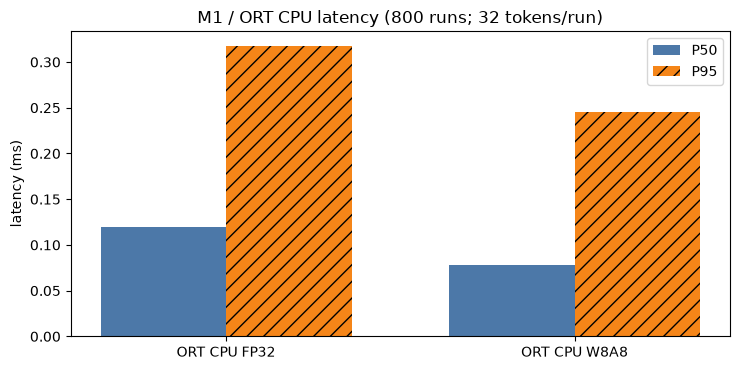

In [32]:
benchmark_input = evaluation_inputs[0]
benchmark_sessions = {
    "ORT CPU FP32": fp32_session,
    "ORT CPU W8A8": w8a8_session,
}

latency_rows = []
for backend, session in benchmark_sessions.items():
    for _ in range(WARMUP):
        session.run(None, {"input": benchmark_input})
    for iteration in range(RUNS):
        start = time.perf_counter_ns()
        session.run(None, {"input": benchmark_input})
        latency_rows.append(
            {
                "backend": backend,
                "iteration": iteration,
                "latency_ms": (time.perf_counter_ns() - start) / 1e6,
            }
        )

latency_df = pd.DataFrame(latency_rows)
benchmark_summary = (
    latency_df.groupby("backend", as_index=False)
    .agg(
        p50_ms=("latency_ms", lambda values: np.percentile(values, 50)),
        p95_ms=("latency_ms", lambda values: np.percentile(values, 95)),
        p99_ms=("latency_ms", lambda values: np.percentile(values, 99)),
        mean_ms=("latency_ms", "mean"),
        std_ms=("latency_ms", "std"),
    )
)
benchmark_summary["tokens_per_second_at_p50"] = (
    TOKEN_COUNT * 1000 / benchmark_summary["p50_ms"]
)
fp32_p50 = benchmark_summary.loc[
    benchmark_summary["backend"] == "ORT CPU FP32", "p50_ms"
].item()
w8a8_p50 = benchmark_summary.loc[
    benchmark_summary["backend"] == "ORT CPU W8A8", "p50_ms"
].item()
observed_speedup = fp32_p50 / w8a8_p50
display(benchmark_summary.style.format({
    "p50_ms": "{:.4f}",
    "p95_ms": "{:.4f}",
    "p99_ms": "{:.4f}",
    "mean_ms": "{:.4f}",
    "std_ms": "{:.4f}",
    "tokens_per_second_at_p50": "{:,.0f}",
}))

x = np.arange(len(benchmark_summary))
width = 0.36
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(
    x - width / 2,
    benchmark_summary["p50_ms"],
    width,
    color=BLUE,
    label="P50",
)
ax.bar(
    x + width / 2,
    benchmark_summary["p95_ms"],
    width,
    color=ORANGE,
    hatch="//",
    label="P95",
)
ax.set(
    title=f"M1 / ORT CPU latency ({RUNS} runs; {TOKEN_COUNT} tokens/run)",
    ylabel="latency (ms)",
    xticks=x,
    xticklabels=benchmark_summary["backend"],
    ylim=(0, None),
)
ax.legend()
fig.tight_layout()
plt.show()

如果 W8A8 没变快，不要立刻改 calibration。先按 compiler/runtime 顺序查：

1. optimized graph 是否出现 `QGemm` / quantized kernel？
2. 是否仍有很多 `Q → DQ`、layout transpose 或 fallback boundary？
3. workload 是否太小，以至于 dispatch / conversion overhead 大于 INT8 compute 节省？
4. target CPU/NPU 是否有对应 dot-product / matrix ISA，shape 是否满足 alignment？
5. thread、warmup、power/thermal、输入 shape 是否严格一致？

这是关键的求职叙事：**先证明执行路径，再解释 performance；不要从 latency 反猜 graph。**

## Checks 4：profiler 证明 quantized kernel 与 conversion boundary

optimized graph 是编译后静态证据；profiler 是 runtime 事件证据。下面单独创建 profiling session，只跑少量 iteration，并按 `op_name / provider` 聚合时间。profile duration 带 instrumentation overhead，不能替代上一节 benchmark。

In [33]:
def profile_ort_model(model_path: Path, prefix: Path):
    options = ort.SessionOptions()
    options.intra_op_num_threads = CPU_THREADS
    options.inter_op_num_threads = 1
    options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    options.enable_profiling = True
    options.profile_file_prefix = str(prefix)
    options.log_severity_level = 3
    session = ort.InferenceSession(
        str(model_path), options, providers=["CPUExecutionProvider"]
    )
    for _ in range(10):
        session.run(None, {"input": benchmark_input})
    profile_path = Path(session.end_profiling())
    events = json.loads(profile_path.read_text(encoding="utf-8"))
    node_rows = [
        {
            "name": event["name"],
            "duration_us": event["dur"],
            "op_name": event.get("args", {}).get("op_name", "unknown"),
            "provider": event.get("args", {}).get("provider", "unknown"),
        }
        for event in events
        if event.get("cat") == "Node"
    ]
    return profile_path, pd.DataFrame(node_rows)

w8a8_profile_path, w8a8_profile_events = profile_ort_model(
    W8A8_QDQ_ONNX, PROFILE_DIR / "ort_w8a8"
)
profile_summary = (
    w8a8_profile_events.groupby(["op_name", "provider"], as_index=False)
    .agg(calls=("duration_us", "size"), total_us=("duration_us", "sum"))
    .sort_values("total_us", ascending=False)
)
profile_summary["time_share_pct"] = (
    100 * profile_summary["total_us"] / profile_summary["total_us"].sum()
)
quantized_kernel_names = {"QGemm", "QLinearMatMul", "MatMulInteger"}
conversion_names = {"QuantizeLinear", "DequantizeLinear", "Transpose"}
quantized_kernel_seen = profile_summary["op_name"].isin(quantized_kernel_names).any()
conversion_time_share = profile_summary.loc[
    profile_summary["op_name"].isin(conversion_names), "time_share_pct"
].sum()
assert quantized_kernel_seen
display(profile_summary.head(12).style.format({
    "total_us": "{:,.0f}",
    "time_share_pct": "{:.1f}%",
}))
print(f"profile JSON: {w8a8_profile_path.relative_to(ROOT)}")
print(f"Q/DQ/layout conversion time share in profiled node events: {conversion_time_share:.1f}%")

,op_name,provider,calls,total_us,time_share_pct
1,QGemm,CPUExecutionProvider,30,"1,922",62.2%
2,QuantizeLinear,CPUExecutionProvider,30,453,14.7%
0,DequantizeLinear,CPUExecutionProvider,30,365,11.8%
3,Relu,CPUExecutionProvider,20,351,11.4%


profile JSON: results/project2_quantization/20260902-225231/profiler/ort_w8a8_2026-09-02_22-58-55_460.json
Q/DQ/layout conversion time share in profiled node events: 26.5%


### 证据阶梯：面试时不要把五层证据压成一句“支持 INT8”

| 层级 | 本实验的证据 | 能证明什么 | 还不能证明什么 |
|---|---|---|---|
| 1. Precision intent | raw ONNX 有 Q/DQ + scale/zp | frontend graph 表达 W8A8 | backend 会接受 |
| 2. Compiler rewrite | optimized graph 有 `QGemm` | ORT optimizer 匹配 quantized pattern | 真实事件执行了谁 |
| 3. Runtime mapping | profile `op_name=QGemm`, provider=CPU EP | quantized runtime kernel 被调用 | 一定更快 / 一定省功耗 |
| 4. Performance | 同 protocol 的 P50/P95 | 当前机器、shape、runtime 的实际 latency | 公司 NPU 的收益 |
| 5. Quality | logits error / agreement；正式项目加 task metric | 精度代价是否可接受 | 未覆盖分布上的稳健性 |

在 Custom NPU 上，把 `QGemm` 替换为 vendor profiler 中的 INT8 kernel/task 名，把 CPU EP 替换为 NPU partition/device ID。

## Checks 5：calibration / evaluation data quality gate

本实验 synthetic data 的 grain 是“一行 = 一个 `[32,256]` token matrix”。它有固定 seed、shape 和分布，适合重现实验机制；但它没有生产语义、真实 preprocessing 或 label，因此不允许支持 ResNet/Transformer accuracy 决策。

In [34]:
def dataset_profile(name: str, samples: list[np.ndarray], intended_use: str):
    values = np.concatenate(samples, axis=0)
    return {
        "dataset": name,
        "matrix batches": len(samples),
        "token rows": len(values),
        "shape valid %": 100
        * np.mean([sample.shape == INPUT_SHAPE for sample in samples]),
        "finite values %": 100 * np.isfinite(values).mean(),
        "min": values.min(),
        "max": values.max(),
        "P99.9 abs": np.percentile(np.abs(values), 99.9),
        "intended use": intended_use,
    }

dataset_quality = pd.DataFrame(
    [
        dataset_profile("calibration", calibration_inputs, "derive quant params; smoke only"),
        dataset_profile("evaluation", evaluation_inputs, "in-distribution numerical check"),
        dataset_profile("shifted", shifted_inputs, "distribution-shift stress check"),
    ]
)
display(dataset_quality.style.format({
    "shape valid %": "{:.1f}%",
    "finite values %": "{:.1f}%",
    "min": "{:.3f}",
    "max": "{:.3f}",
    "P99.9 abs": "{:.3f}",
}))

,dataset,matrix batches,token rows,shape valid %,finite values %,min,max,P99.9 abs,intended use
0,calibration,24,768,100.0%,100.0%,-4.427,4.397,3.289,derive quant params; smoke only
1,evaluation,8,256,100.0%,100.0%,-4.115,4.556,3.307,in-distribution numerical check
2,shifted,8,256,100.0%,100.0%,-47.925,56.727,16.223,distribution-shift stress check


正式模型至少增加这些 checks：

- calibration 与 production 的 preprocessing、shape bucket、dtype 完全一致；
- 类别/场景/长度/分辨率覆盖，而不是从同一张图复制几十次；
- 比较 calibration 与 evaluation 的 activation range / saturation / distribution drift；
- evaluation dataset 有 label，报告 FP16 与 W8A8 的同一个 task metric；
- calibration sample 不与 final evaluation 重复，避免挑数据调 scale；
- 固定 dataset manifest/hash，避免每次实验样本悄悄变化。

**当前 validation 结论：** notebook 可作为 mechanism tutorial 分享；不可把 toy correctness 或 M1 CPU speedup 写成 ResNet、Transformer 或 Custom NPU 的 production 结论。

## 迁移到公司 Custom NPU：同一份 graph 应怎样编译、测试、调试、优化

vendor CLI 未知，所以不能编造真实 flag。下面给的是**接口合同模板**；把尖括号替换为公司工具的真实命令，并把完整命令保存下来。

```bash
<npu-compiler> \
  --model artifacts/project2_quantization/tiny_token_mlp_w8a8_qdq.onnx \
  --target <soc-revision> \
  --dump-ir <run-dir>/compiler_ir \
  --dump-partition <run-dir>/partition.json \
  --output <run-dir>/model.bin

<npu-runner> \
  --model <run-dir>/model.bin \
  --input <run-dir>/input.bin \
  --warmup 50 \
  --runs 800 \
  --output <run-dir>/output.bin

<npu-profiler> \
  --model <run-dir>/model.bin \
  --output <run-dir>/profiler
```

参数的大白话：

- `--target` 固定 SoC revision / firmware / ISA contract；
- `--dump-ir` 检查 Q/DQ 在哪一层被消除、scale 怎样进入 quantized op；
- `--dump-partition` 找 NPU coverage 与 CPU/DSP fallback boundary；
- `--warmup / --runs` 把首次加载与稳态 latency 分开；
- profiler 至少记录 task/kernel、cycle、DDR bytes、on-chip memory、conversion/layout task。

建议对同一 model/input 连续编译 FP16 与 W8A8，不能只测一个 precision：

```text
same FP32 reference / same input / same correctness gate
             ├── FP16 compile → graph/task/kernel/profile
             └── W8A8 compile → graph/task/kernel/profile
```

In [15]:
soc_measurement_columns = [
    "experiment_id",
    "compiler_version",
    "runtime_version",
    "firmware_version",
    "target_soc",
    "precision",
    "model_sha256",
    "compile_time_ms",
    "artifact_size_mb",
    "raw_qdq_count",
    "post_lowering_qdq_count",
    "npu_partition_coverage_pct",
    "fallback_op_count",
    "conversion_boundary_count",
    "selected_matmul_kernel",
    "p50_ms",
    "p95_ms",
    "dram_read_mb",
    "onchip_sram_hit_pct",
    "mean_output_cosine",
    "task_accuracy",
]
soc_measurement_template = pd.DataFrame(
    [
        {"experiment_id": f"{RUN_ID}-fp16", "precision": "FP16"},
        {"experiment_id": f"{RUN_ID}-w8a8", "precision": "W8A8"},
    ],
    columns=soc_measurement_columns,
).fillna("")
SOC_TEMPLATE_PATH = RUN_DIR / "soc_measurement_template.csv"
soc_measurement_template.to_csv(SOC_TEMPLATE_PATH, index=False)

vendor_command_template = '''<npu-compiler> --model <model.onnx> --target <soc> --dump-ir <dir> --dump-partition <file> --output <model.bin>
<npu-runner> --model <model.bin> --input <input.bin> --warmup 50 --runs 800 --output <output.bin>
<npu-profiler> --model <model.bin> --output <profiler-dir>
'''
(RUN_DIR / "vendor_command_template.txt").write_text(
    vendor_command_template, encoding="utf-8"
)
display(soc_measurement_template)
print(f"SoC measurement template: {SOC_TEMPLATE_PATH.relative_to(ROOT)}")

,experiment_id,compiler_version,runtime_version,firmware_version,target_soc,precision,model_sha256,compile_time_ms,artifact_size_mb,raw_qdq_count,...,npu_partition_coverage_pct,fallback_op_count,conversion_boundary_count,selected_matmul_kernel,p50_ms,p95_ms,dram_read_mb,onchip_sram_hit_pct,mean_output_cosine,task_accuracy
0,20260829-141510-fp16,,,,,FP16,,,,,...,,,,,,,,,,
1,20260829-141510-w8a8,,,,,W8A8,,,,,...,,,,,,,,,,


SoC measurement template: results/project2_quantization/20260829-141510/soc_measurement_template.csv


### Custom NPU 两类常见故障的最短排查路径

**A. accuracy / agreement 掉得多：**

```text
reference/preprocess 一致？
    ↓ yes
calibration 是否 representative、是否 saturation？
    ↓ yes
FP32 vs W8A8 中间 activation：哪层 SQNR/cosine 先恶化？
    ↓
对 top-sensitive layer 做 FP16 fallback
    ↓
recompile：QDQ boundary / fusion / partition 是否改变？
```

**B. latency 没收益甚至变慢：**

```text
QDQ graph 被 compiler 接受？
    ↓
post-lowering 是否真有 INT8 op/kernel？
    ↓
partition coverage / fallback / layout conversion？
    ↓
shape alignment / tile / SRAM / DDR traffic？
    ↓
profile cycle 归因到 kernel 还是 conversion/dispatch？
```

不要交叉乱跳：数值问题先走 activation evidence，性能问题先走 compiler/runtime evidence；最后再看两者如何通过 selective fallback 相互影响。

## 保存可复现实验记录

本次运行保存 model hash、quant config、dataset contract、raw/optimized graph stats、全部 latency、correctness、profile summary 和 SoC template。optimized ONNX 是本机 ORT 的 inspection artifact，不作为跨机器部署模型。

In [35]:
graph_stats = {
    "fp32_preprocessed": dict(fp32_op_counts),
    "w8a8_raw_qdq": dict(qdq_op_counts),
    "fp32_ort_optimized": dict(fp32_optimized_counts),
    "w8a8_ort_optimized": dict(w8a8_optimized_counts),
}
quantization_config = {
    "method": "static PTQ",
    "format": "QDQ",
    "calibration_method": "MinMax",
    "activation": "symmetric int8 per-tensor",
    "weight": "symmetric int8 per-output-channel",
    "calibration_provider": "CPUExecutionProvider",
    "calibration_batches": CALIBRATION_BATCHES,
}
dataset_contract = {
    "kind": "deterministic synthetic smoke data",
    "calibration_seed": 101,
    "evaluation_seed": 202,
    "shifted_seed": 303,
    "labels_available": False,
    "allowed_claim": "mechanism and numerical agreement only",
    "forbidden_claim": "task accuracy or production representativeness",
}
artifact_manifest = {
    name: {
        "path": str(path.relative_to(ROOT)),
        "sha256": sha256_file(path),
        "size_mb": size_mb(path),
    }
    for name, path in {
        "fp32_onnx": FP32_ONNX,
        "fp32_preprocessed_onnx": PREPROCESSED_ONNX,
        "w8a8_qdq_onnx": W8A8_QDQ_ONNX,
        "fp32_ort_optimized_onnx": FP32_OPTIMIZED_ONNX,
        "w8a8_ort_optimized_onnx": W8A8_OPTIMIZED_ONNX,
        "w8a8_ort_profile": w8a8_profile_path,
    }.items()
}
manifest = {
    "environment": environment,
    "model_contract": model_contract,
    "quantization_config": quantization_config,
    "dataset_contract": dataset_contract,
    "benchmark_protocol": {
        "warmup": WARMUP,
        "runs": RUNS,
        "scope": "prepared [32,256] float tensor to host-visible logits",
        "provider": "CPUExecutionProvider",
    },
    "artifacts": artifact_manifest,
    "graph_stats": graph_stats,
}

(RUN_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8"
)
(RUN_DIR / "graph_stats.json").write_text(
    json.dumps(graph_stats, indent=2, ensure_ascii=False), encoding="utf-8"
)
activation_stats.to_csv(RUN_DIR / "calibration_activation_stats.csv", index=False)
dataset_quality.to_csv(RUN_DIR / "dataset_quality.csv", index=False)
correctness_df.to_csv(RUN_DIR / "correctness.csv", index=False)
latency_df.to_csv(RUN_DIR / "runtime.csv", index=False)
benchmark_summary.to_csv(RUN_DIR / "benchmark_summary.csv", index=False)
profile_summary.to_csv(RUN_DIR / "profiler_summary.csv", index=False)

display(pd.DataFrame(artifact_manifest).T)
display(Markdown(f"本次实验结果目录：`{RUN_DIR.relative_to(ROOT)}`"))

,path,sha256,size_mb
fp32_onnx,artifacts/project2_quantization/tiny_token_mlp_fp32.onnx,94d6f287fd0be45287747b454c32cb7761ee40e1834d1748ee52a9f3a957faa0,1.585897
fp32_preprocessed_onnx,artifacts/project2_quantization/tiny_token_mlp_fp32_preprocessed.onnx,e27a10971dfc5b1722840434a54080e40e0d260cd1c48ff144c3f92a1a26b55a,1.586315
w8a8_qdq_onnx,artifacts/project2_quantization/tiny_token_mlp_w8a8_qdq.onnx,218944b1296a0e183666d5f2e74d812c407200427c48d5acd950d26e55f3a9d2,0.41799
fp32_ort_optimized_onnx,artifacts/project2_quantization/tiny_token_mlp_fp32_ort_optimized.onnx,91c2d7685ecba38a7c403552a15b12e0ef9fdac4ad3322f3d1e668cc94bba882,1.586424
w8a8_ort_optimized_onnx,artifacts/project2_quantization/tiny_token_mlp_w8a8_ort_optimized.onnx,c0204b4eed13166d2922e0730977a11f500b19d7e7e95d3c59520b0bb17c33ca,0.408068
w8a8_ort_profile,results/project2_quantization/20260902-225231/profiler/ort_w8a8_2026-09-02_22-58-55_460.json,f3e78e9ee96b01ff3d71acd58fbb2d353e7aacd2633c59a80f96586790525cdf,0.113343


本次实验结果目录：`results/project2_quantization/20260902-225231`

## Takeaways：只根据这一次 executed run 能支持的证据说话

In [36]:
in_distribution_row = correctness_df.set_index("dataset").loc[
    "in-distribution synthetic"
]
shifted_row = correctness_df.set_index("dataset").loc[
    "shifted + outliers synthetic"
]
raw_qdq_count = qdq_op_counts["QuantizeLinear"] + qdq_op_counts["DequantizeLinear"]
optimized_qdq_count = (
    w8a8_optimized_counts["QuantizeLinear"]
    + w8a8_optimized_counts["DequantizeLinear"]
)
quantized_compute_count = sum(
    w8a8_optimized_counts[name]
    for name in ["QGemm", "QLinearMatMul", "MatMulInteger"]
)
weight_mae_improvement = (
    np.mean(per_tensor_channel_mae) / np.mean(per_channel_channel_mae)
)
artifact_size_ratio = size_mb(PREPROCESSED_ONNX) / size_mb(W8A8_QDQ_ONNX)
performance_sentence = (
    f"W8A8 P50 比 FP32 快 {observed_speedup:.2f}×"
    if observed_speedup >= 1
    else f"W8A8 P50 只有 FP32 的 {observed_speedup:.2f}×，本次没有 latency 收益"
)

display(
    Markdown(
        f'''
- **数值表示：** symmetric INT8 用 `scale` 把 float range 映射到 `[-127,127]`；一个 outlier 会放大 scale，并提高普通值的 rounding error。
- **Granularity：** `fc1` 的 per-output-channel weight quantization 使用 {weight_per_channel_scale.size} 个 scale；在这个受控 toy weight 上，mean reconstruction MAE 比 per-tensor 降低 **{weight_mae_improvement:.2f}×**。
- **Compiler evidence：** raw graph 有 **{raw_qdq_count}** 个 Q/DQ node；ORT optimized graph 剩 **{optimized_qdq_count}** 个 Q/DQ，并出现 **{quantized_compute_count}** 个 quantized compute op。说明 pattern 被识别，但边界不一定全部消失。
- **Artifact：** W8A8 QDQ ONNX 比 FP32 preprocessed ONNX 小 **{artifact_size_ratio:.2f}×**；这是磁盘 artifact size，不等于 runtime peak memory。
- **Runtime evidence：** profiler 看到了 quantized kernel；Q/DQ/layout conversion 占被记录 node time 的 **{conversion_time_share:.1f}%**。profile time 仅用于归因，不替代 benchmark。
- **Correctness：** in-distribution synthetic 的 mean cosine 为 **{in_distribution_row['mean cosine']:.6f}**、Top-1 agreement 为 **{in_distribution_row['Top-1 agreement %']:.2f}%**；shifted set 的 input saturation 为 **{shifted_row['input saturation %']:.3f}%**。这些是 agreement / stress evidence，不是 task accuracy。
- **Performance：** 在这台机器的 ORT CPU lane，{performance_sentence}。该结论只覆盖当前 shape、runtime、thread 与 power/thermal 状态。
- **Validation status：** **mechanism tutorial 可分享；Custom NPU precision/performance 决策仍缺真实 calibration/evaluation data、vendor compiler dump 和 SoC profiler。**
        '''
    )
)


- **数值表示：** symmetric INT8 用 `scale` 把 float range 映射到 `[-127,127]`；一个 outlier 会放大 scale，并提高普通值的 rounding error。
- **Granularity：** `fc1` 的 per-output-channel weight quantization 使用 512 个 scale；在这个受控 toy weight 上，mean reconstruction MAE 比 per-tensor 降低 **2.56×**。
- **Compiler evidence：** raw graph 有 **18** 个 Q/DQ node；ORT optimized graph 剩 **6** 个 Q/DQ，并出现 **3** 个 quantized compute op。说明 pattern 被识别，但边界不一定全部消失。
- **Artifact：** W8A8 QDQ ONNX 比 FP32 preprocessed ONNX 小 **3.80×**；这是磁盘 artifact size，不等于 runtime peak memory。
- **Runtime evidence：** profiler 看到了 quantized kernel；Q/DQ/layout conversion 占被记录 node time 的 **26.5%**。profile time 仅用于归因，不替代 benchmark。
- **Correctness：** in-distribution synthetic 的 mean cosine 为 **0.999781**、Top-1 agreement 为 **99.22%**；shifted set 的 input saturation 为 **7.979%**。这些是 agreement / stress evidence，不是 task accuracy。
- **Performance：** 在这台机器的 ORT CPU lane，W8A8 P50 比 FP32 快 1.54×。该结论只覆盖当前 shape、runtime、thread 与 power/thermal 状态。
- **Validation status：** **mechanism tutorial 可分享；Custom NPU precision/performance 决策仍缺真实 calibration/evaluation data、vendor compiler dump 和 SoC profiler。**
        

## Next Steps

1. **先把 toy lane 迁到公司 SoC：** 用上面的 `soc_measurement_template.csv` 补齐 FP16/W8A8 的 compiler version、partition、kernel、P50/P95、memory traffic 和 correctness；不要先改 model。
2. **把 ResNet-50 换回真实数据：** 复用 Project 1 的 `artifacts/resnet50/resnet50_imagenet1k_v2.onnx`，准备独立 calibration/evaluation image manifests；至少报告 FP16/W8A8 的真实 task accuracy 与 latency。
3. **Project 2 · 02：layer sensitivity：** 抓取 FP32/W8A8 对齐的中间 activation，按 layer 计算 cosine / SQNR / saturation，输出 sensitivity ranking。
4. **Project 2 · 03：selective fallback：** 用 `nodes_to_exclude` 或 vendor mixed-precision config 对 Top-1/3/5 sensitive layer 恢复 FP16；每次都 recompile 并重查 QDQ boundary、fusion、partition、kernel。
5. **形成 Pareto：** 横轴 latency，纵轴 task accuracy；只保留不存在“更慢且更差”配置的 Pareto frontier。

ResNet-50 scale-up 时可先查看真实 CLI 帮助：

```bash
uv run python -m onnxruntime.quantization.preprocess --help
```

常用开关的大白话：`--skip_optimization` 保留更多原 graph identity，便于数值 debug；shape inference 则帮助 quantizer 确定 tensor rank/axis。正式流程应先保存 preprocessed graph，再单独 quantize，避免两个阶段混在一次不可追踪的 rewrite 中。

## 附录 A：Quantization 数值与算法术语

| 术语 / 缩写 | 展开与解释 | 在本实验哪里出现 |
|---|---|---|
| FP32 | 32-bit floating point；Project 1/reference 常用高精度基线 | FP32 ONNX / logits reference |
| FP16 | 16-bit floating point；端侧 NPU 常见 baseline | 公司 SoC 对照组；本 M1 toy lane 未伪造 FP16 NPU 结果 |
| INT8 / INT4 | 8-bit / 4-bit integer；bit 更少意味着表示格更少 | W8A8 使用 INT8；INT4 留到硬件 contract 明确后 |
| W8A8 | Weight 8-bit + Activation 8-bit | 本实验 static PTQ 目标 |
| W4A8 | Weight 4-bit + Activation 8-bit | 后续 Custom NPU / MatMul kernel 实验 |
| PTQ | Post-Training Quantization；训练完成后，用 calibration 估范围并量化，不更新 weights | `quantize_static` |
| QAT | Quantization-Aware Training；训练时插入 fake quantization，让 weights 适应量化误差 | PTQ 达不到 quality gate 后才考虑 |
| Calibration | 用 representative inputs 执行 float model，收集 activation statistics | `CalibrationDataReader` + MinMax |
| Representative dataset | 能覆盖生产 preprocessing、shape、类别/场景与长尾的校准样本 | synthetic data **不满足**生产代表性 |
| Linear / affine quantization | 用线性映射在 float 与 integer lattice 间转换 | `q = round(x/scale)+zp` |
| Scale | 一个 integer step 对应多少 float 数值；越大，格越粗 | `input_scale`、`fc1.weight_scale` |
| Zero-point / ZP | 哪个 integer code 精确表示 float 0 | symmetric S8 中为 0 |
| Symmetric | float range 关于 0 对称，通常 `zp=0`，硬件实现简单 | 本实验 activation/weight config |
| Asymmetric | 精确映射 `[min,max]`，通常 `zp≠0`，可能更贴合偏斜分布 | 后续 calibration policy 对比 |
| S8S8 / U8S8 | activation/weight 的 signedness 组合；S=Signed，U=Unsigned | 本实验是 S8S8；Custom NPU 必须查支持矩阵 |
| Per-tensor | 整个 tensor 共用一个 scale/zp | activation baseline |
| Per-channel / per-axis | 沿一个 axis 每个 channel 独立 scale/zp | Linear weight 的 output channel |
| Per-block | 每一小块元素共享 scale/zp；介于 per-tensor 与 per-element 之间 | W4 weight-only / LLM 常见，后续再做 |
| Rounding | 把连续值投到最近 integer code；必然产生误差 | `np.rint` / `QuantizeLinear` |
| Clipping / saturation | 超出 integer range 的值被夹到端点 | shifted input stress test |
| Outlier | 绝对值远大于主体分布的少量值；可能放大 scale | toy value 12 与 shifted set |
| MinMax | 用观察到的最小/最大值定 range；简单但对 outlier 敏感 | baseline calibration method |
| Percentile | 裁掉指定尾部比例后定 range；用少量 saturation 换更细整数格 | 后续 calibration policy |
| Entropy / KL calibration | 搜索使分布信息损失较小的 clipping threshold | 主流 engine 可选，但不是第一步 |
| Observer | 运行时收集中间 tensor 统计量的组件 | 手写 forward hook、ORT calibrator |
| Fake quantization | 在 float 中模拟 Q→DQ 误差，常用于 QAT / sensitivity | 本 notebook 第一性原理函数 |
| Accumulator | INT8×INT8 乘积通常累加到更宽的 INT32，避免立即溢出 | bias scale / NPU kernel contract |
| Requantization | 把 accumulator 或一个 op 的输出重新缩放到下一段 INT8 range | op 之间的 scale conversion |

## 附录 B：Graph / Compiler / Runtime 术语

| 术语 / 缩写 | 展开与解释 | 调试证据 |
|---|---|---|
| IR | Intermediate Representation；compiler pass 读写的图/程序表示 | ONNX、vendor high/mid/low IR dump |
| ONNX | Open Neural Network Exchange；跨框架 graph format | `.onnx` 文件 |
| Protobuf | Protocol Buffers；ONNX 序列化 graph 的数据结构 | `ModelProto / GraphProto / NodeProto` |
| Opset | 一组 ONNX operator schema 的版本合同 | 本实验 opset 18 |
| Q / DQ | Quantize / Dequantize；float↔integer mapping op | `QuantizeLinear / DequantizeLinear` |
| QDQ format | 用 tensor-oriented Q/DQ 包围原 op，表达 quantization intent | raw W8A8 ONNX |
| QOperator format | 用 `QLinearConv` 等专门 quantized op 表达计算 | ORT 的另一种 ONNX quant format |
| Pattern matching | compiler 在 graph 中识别 `DQ→Gemm→Q` 等结构 | optimized graph 出现 `QGemm` |
| Fusion | 多个 op 合成一个 kernel/region，减少 launch 和 memory round-trip | 检查 `DQ→Relu→Q` 是否消失 |
| Partition | 把支持的 subgraph 分给 NPU，剩余部分交给 CPU/DSP | vendor partition report |
| Fallback | unsupported op/shape/precision 退回其他 backend | fallback op count / timeline |
| Lowering | 把高层 op 逐步变成 target-specific task/instruction/kernel call | vendor lowering IR |
| Kernel | 某个 op/workload 在特定硬件上的具体实现 | `QGemm` 或 vendor kernel name |
| EP | Execution Provider；ONNX Runtime 的 backend 插件边界 | `CPUExecutionProvider` |
| Device placement | 每个 op/subgraph 最终在哪个 compute device 执行 | partition + runtime timeline |
| Coverage | 可被目标 backend 接收的 op/subgraph 比例；必须说明按 node、MAC 还是 time 加权 | NPU partition coverage |
| Conversion boundary | precision/layout/device 改变处，常引入 Q/DQ、transpose、DMA | optimized graph + profiler |
| Compiler contract | frontend graph、quant config、target capability、artifact/version 共同约定的输入输出规则 | manifest + command + dump |
| Support matrix | backend 对 op、shape、dtype、granularity、layout 的支持表 | 编译前判断 W8A8/W4A8 可行性 |

## 附录 C：Correctness / Performance / Search 术语

| 术语 / 缩写 | 展开与解释 | 注意点 |
|---|---|---|
| Correctness gate | candidate output 在规定 tolerance / task metric 下必须通过的门槛 | 永远在 performance claim 之前 |
| MAE / MSE | Mean Absolute Error / Mean Squared Error | MSE 对大误差更敏感 |
| Max absolute error | 全部元素中最坏的绝对误差 | 容易被单个 outlier 主导，要配分布图 |
| Cosine similarity | 比较两个向量方向；1 表示方向很接近 | 不反映统一幅值缩放的全部问题 |
| SQNR | Signal-to-Quantization-Noise Ratio；signal power 与量化噪声 power 之比，通常用 dB | P2.2 layer sensitivity |
| Top-1 agreement | 两个 backend argmax 相同的比例 | **没有 label 时不能叫 accuracy** |
| Task accuracy | 与真实 label/任务定义比较的指标 | 正式 ResNet/Transformer report 必须有 |
| P50 / P95 / P99 | latency 分布的 50/95/99 percentile | 不只报最快一次或 mean |
| Throughput / QPS | 单位时间处理的 token/sample/query 数 | batch/token 数必须写清 |
| Warmup | 统计前触发 cache、lazy initialization、frequency state | 与 first run 分开 |
| Profiler | 记录 op/kernel/timeline/counter 的 instrumentation | 有 overhead，不替代 benchmark |
| Layer sensitivity | 单层量化或 fallback 对 output/task metric 的影响 | 要对齐同一 layer activation |
| Selective fallback | 只把敏感层恢复 FP16/FP32 | 每次都可能改变 fusion/partition |
| Mixed precision | 不同 layer/op 使用不同 precision | 目标是全局 accuracy-latency trade-off |
| Pareto frontier | 不存在另一个配置同时“更准且更快”的候选集合 | Project 2 最终输出 |
| Hardware-aware | precision decision 同时考虑 accuracy、kernel、fusion、fallback、memory 与 latency | 不是只看 fake-quant error |

## 附录 D：高频面试自检

1. **为什么 weight quantization 不需要 calibration，而 activation quantization 通常需要？**
   - weights 是 graph artifact 中的常量；activation range 是输入相关的 runtime state。
2. **为什么 per-channel weight 通常比 per-tensor 更准？**
   - 每个 output channel 独立使用 integer dynamic range，不被全局最大 channel 拉粗 scale。
3. **QDQ graph 已生成，为什么可能没有加速？**
   - backend 可能不支持该 op/shape/dtype；可能 fallback；Q/DQ/layout boundary 可能保留；可能 workload 太小；硬件可能没有对应 INT8 path。
4. **如何证明“真的跑了 INT8”？**
   - post-lowering graph/task 显示 quantized op，runtime profiler 显示 INT8 kernel/device，hardware counter 与 latency/memory 一起闭环。
5. **量化 accuracy 掉了，第一步做什么？**
   - 先验证 reference/preprocessing 与 calibration representativeness，再找第一处 activation error 明显放大的 layer，不直接全局调参。
6. **为什么 selective fallback 必须 recompile？**
   - precision boundary 会改变 Q/DQ、fusion、partition 与 kernel selection，静态估计无法代替重新编译和实测。
7. **M1 上 ORT CPU 的 W8A8 speedup 能说明公司 NPU 什么？**
   - 只能证明实验方法和该 CPU backend 的结果；不能外推 NPU speedup，但 graph/correctness/benchmark/profiler 的证据链可原样迁移。

## 官方参考

- [ONNX Runtime — Quantize ONNX models](https://onnxruntime.ai/docs/performance/model-optimizations/quantization.html)：static/dynamic quantization、QDQ/QOperator、pre-process、debug API 与 INT4 支持边界。
- [ONNX — QuantizeLinear](https://onnx.ai/onnx/operators/onnx__QuantizeLinear.html)：quantization 公式、rounding、saturation 与 granularity schema。
- [ONNX — DequantizeLinear](https://onnx.ai/onnx/operators/onnx__DequantizeLinear.html)：`(x - zero_point) * scale` 与 per-axis contract。
- [Core ML Tools — Optimization overview](https://apple.github.io/coremltools/docs-guides/source/opt-overview.html)：weight/activation quantization 与 W8A8 hardware availability。
- [Core ML Tools — Quantization API overview](https://apple.github.io/coremltools/docs-guides/source/opt-quantization-api.html)：weight-only 与 activation+weight workflow；注意仓库锁定的 Core ML Tools 9.0 已把部分 API 从旧文档的 experimental namespace 移出。
- [Core ML Tools releases](https://github.com/apple/coremltools/releases)：本仓库锁定 9.0，官方 release note 标注 PyTorch 2.7 支持。

版本变化会影响 API 和 backend 支持。运行本 notebook 时，以顶部 environment table、`uv.lock` 和公司 NPU 的 compiler/runtime/firmware version 为实验事实，不以记忆中的默认值代替版本合同。